# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [172]:
train = pd.read_csv('shoes_sales_dataset.csv')
train.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


### Exploratory Data Analysis

In [173]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [174]:
d = train.describe()
d

,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


/tmp/ipykernel_40710/3868724274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sales_Channel', data=train, palette='RdBu_r')


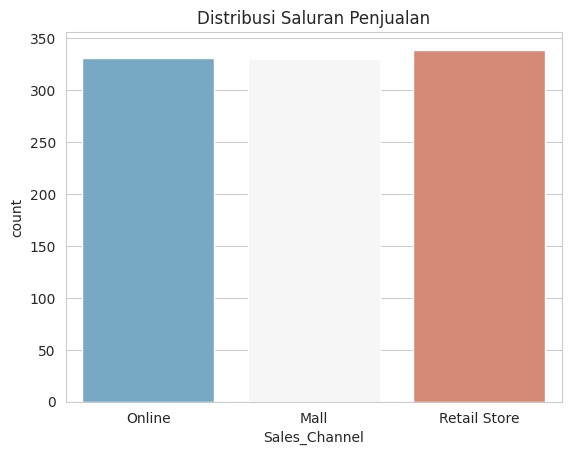

In [175]:
# Cek relative size dari Sales Channel (Online vs Mall)
sns.set_style('whitegrid')
sns.countplot(x='Sales_Channel', data=train, palette='RdBu_r')
plt.title('Distribusi Saluran Penjualan')
plt.show()

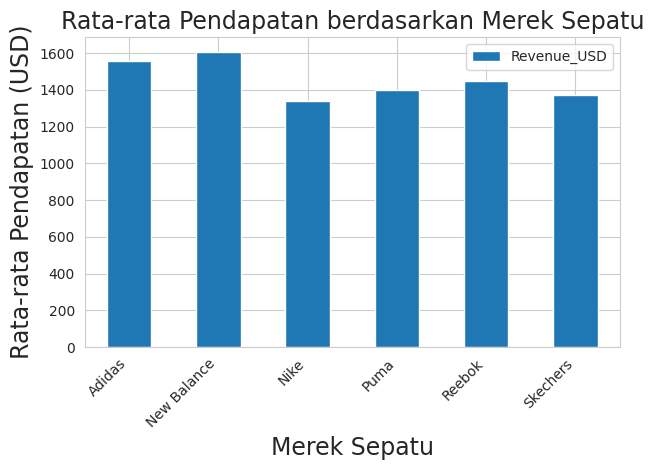

In [176]:
#menghitung rata-rata pendapatan berdasarkan merek sepatu
f_brand_revenue = train.groupby('Brand')['Revenue_USD'].mean()
f_brand_revenue = pd.DataFrame(f_brand_revenue)
f_brand_revenue.plot.bar(y='Revenue_USD')
plt.title("Rata-rata Pendapatan berdasarkan Merek Sepatu",fontsize=17)
plt.xlabel("Merek Sepatu", fontsize=17)
plt.ylabel("Rata-rata Pendapatan (USD)", fontsize=17)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

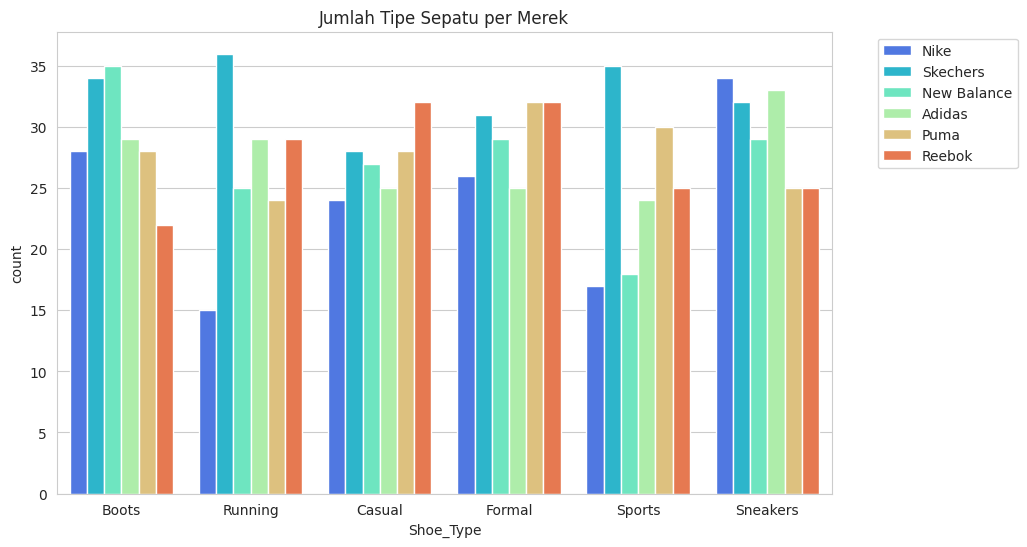

In [177]:
# Distribusi Tipe Sepatu berdasarkan Merek sepatu
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.countplot(x='Shoe_Type', hue='Brand', data=train, palette='rainbow')
plt.title('Jumlah Tipe Sepatu per Merek')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

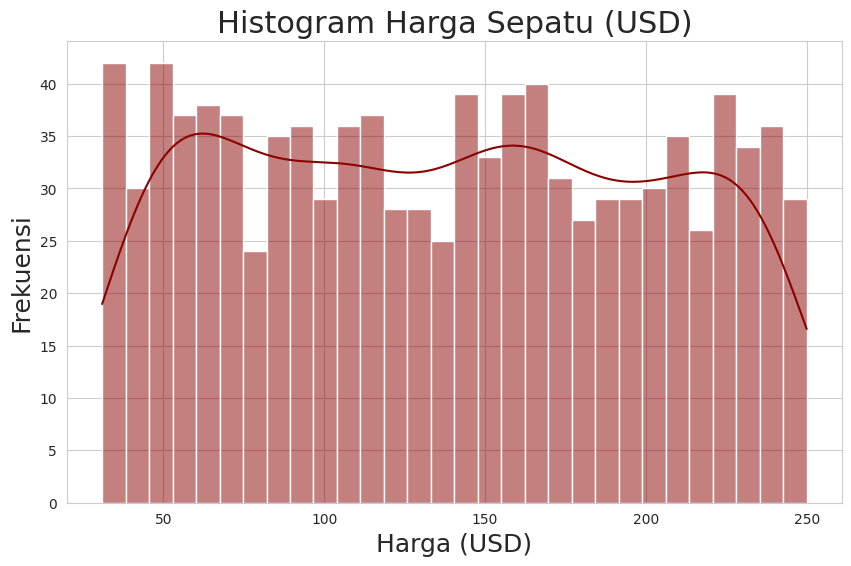

In [178]:
#Histogram Distribusi Harga Sepatu
plt.figure(figsize=(10,6))
sns.histplot(train['Price_USD'], bins=30, color='darkred', kde=True)
plt.title('Histogram Harga Sepatu (USD)', fontsize=22)
plt.xlabel('Harga (USD)', fontsize=18)
plt.ylabel('Frekuensi', fontsize=18)
plt.show()

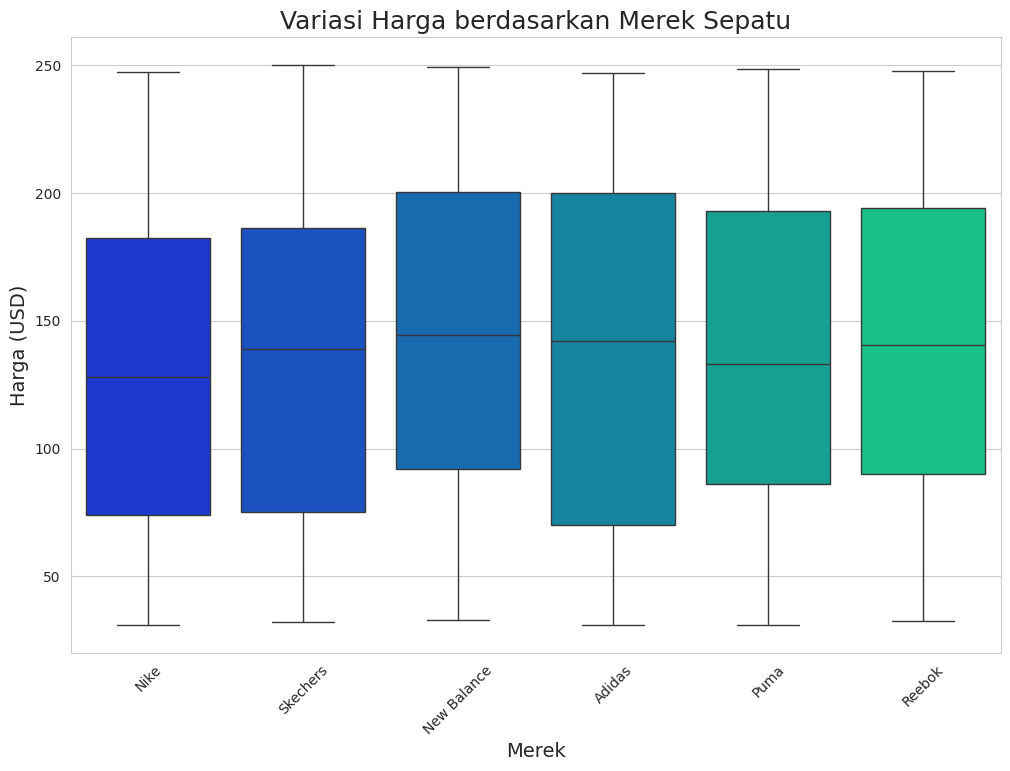

In [179]:
# Distribusi Harga berdasarkan Merek
plt.figure(figsize=(12, 8))
sns.boxplot(x='Brand', y='Price_USD', data=train, palette='winter', hue='Brand', legend=False)
plt.title('Variasi Harga berdasarkan Merek Sepatu', fontsize=18)
plt.xlabel('Merek', fontsize=14)
plt.ylabel('Harga (USD)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

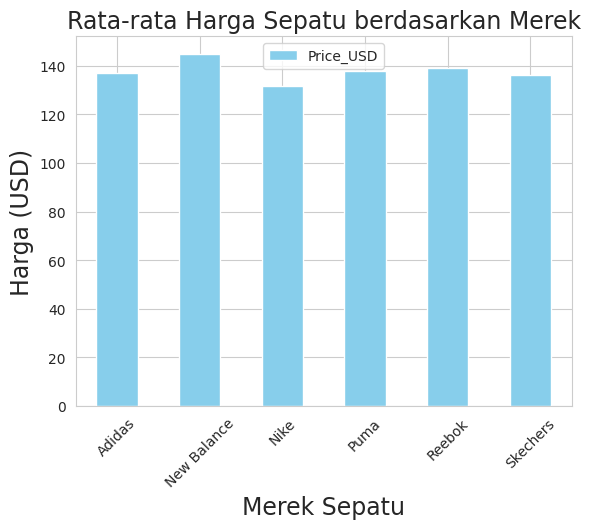

In [180]:
# Menghitung rata-rata harga berdasarkan merek sepatu
f_brand_Price = train.groupby('Brand')['Price_USD'].mean()
f_brand_Price = pd.DataFrame(f_brand_Price)
f_brand_Price.plot.bar(y='Price_USD', color='skyblue')
plt.title("Rata-rata Harga Sepatu berdasarkan Merek", fontsize=17)
plt.ylabel("Harga (USD)", fontsize=17)
plt.xlabel("Merek Sepatu", fontsize=17)
plt.xticks(rotation=45)
plt.show()

### Fitur Engineering

In [181]:
from sklearn.preprocessing import LabelEncoder

# Menghapus kolom yang tidak diperlukan untuk pemodelan
df_model = train.drop(['Sale_ID', 'Date'], axis=1)

# Encoding variabel kategorikal
le = LabelEncoder()
cat_cols = ['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,2,0,1,5,1,112.40,4,449.60
1,5,0,3,6,0,239.16,4,956.64
2,2,3,5,5,0,191.04,2,382.08
3,1,1,2,4,0,161.70,1,161.70
4,0,2,3,0,1,64.32,14,900.48


In [182]:
# Mengecek apakah ada data yang kosong (null) di dataset sepatu
train.isnull().sum()

,0
Sale_ID,0
Date,0
Brand,0
Shoe_Type,0
Color,0
Country,0
Sales_Channel,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

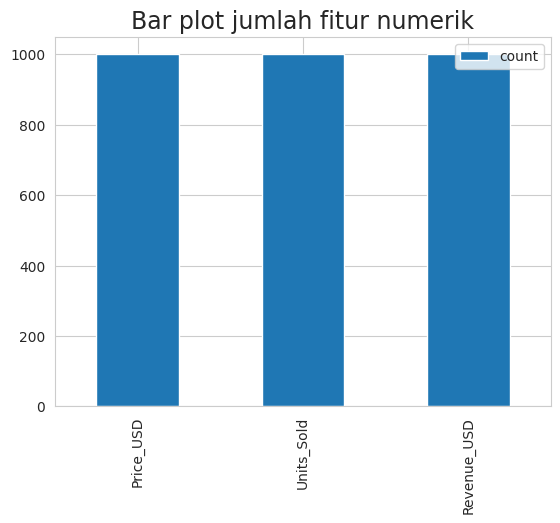

In [183]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [184]:
# Dataset sepatu tidak memiliki kolom 'Cabin' atau banyak data kosong.
# Kita cukup menggunakan df_model yang sudah disiapkan di atas.
train.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


In [185]:
# Sel ini sebelumnya berisi kode Titanic. Kita hapus karena tidak relevan.
print("Fitur yang digunakan untuk model:", X.columns.tolist())

Fitur yang digunakan untuk model: ['Brand', 'Shoe_Type', 'Color', 'Country', 'Price_USD', 'Units_Sold', 'Revenue_USD']


In [186]:
# Label Encoding sudah dilakukan pada sel '50c9kY3fcB-G' menggunakan df_model.
df_model.head()

,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,2,0,1,5,1,112.40,4,449.60
1,5,0,3,6,0,239.16,4,956.64
2,2,3,5,5,0,191.04,2,382.08
3,1,1,2,4,0,161.70,1,161.70
4,0,2,3,0,1,64.32,14,900.48


### Training

In [187]:
from sklearn.model_selection import train_test_split

# Membagi fitur dan target (Target: Sales_Channel)
X = df_model.drop('Sales_Channel', axis=1)
y = df_model['Sales_Channel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (700, 7)
Test shape: (300, 7)


In [188]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (700, 7)
Test shape: (300, 7)


# **KNN**

In [189]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [190]:
y_pred = clf1.predict(X_test)

### Evaluation

In [191]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.33
Confusion Matrix:
[[41 30 21]
 [43 36 27]
 [39 41 22]]
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.45      0.38        92
           1       0.34      0.34      0.34       106
           2       0.31      0.22      0.26       102

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.32       300



# **Naive Bayes**

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Pastikan data terbagi sebelum training
X = df_model.drop('Sales_Channel', axis=1)
y = df_model['Sales_Channel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Inisialisasi dan latih model Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)
print("Model Naive Bayes berhasil dilatih dan siap dievaluasi.")

Model Naive Bayes berhasil dilatih dan siap dievaluasi.


### Evaluation

In [193]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model Naive Bayes
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.33
Confusion Matrix:
[[40 17 35]
 [50 20 36]
 [40 24 38]]
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.43      0.36        92
           1       0.33      0.19      0.24       106
           2       0.35      0.37      0.36       102

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.32       300
weighted avg       0.33      0.33      0.32       300



# **Decision Tree**

In [194]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [195]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model Decision Tree
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.29
Confusion Matrix:
[[25 27 40]
 [42 28 36]
 [35 32 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.27      0.26        92
           1       0.32      0.26      0.29       106
           2       0.32      0.34      0.33       102

    accuracy                           0.29       300
   macro avg       0.29      0.29      0.29       300
weighted avg       0.30      0.29      0.29       300



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [196]:
# Contoh prediksi data baru disesuaikan dengan fitur dataset sepatu
# Urutan: Price_USD, Units_Sold, dll (sesuai hasil engineering nanti)
# new_data = np.array([[150.0, 5]])
# prediction = nb.predict(new_data)

Prediksi Saluran Penjualan (Label): 0
Probabilitas per Kategori: [0.4 0.2 0.4]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [197]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [198]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.34
Confusion Matrix:
[[32 33 27]
 [31 37 38]
 [29 40 33]]
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.35      0.35        92
           1       0.34      0.35      0.34       106
           2       0.34      0.32      0.33       102

    accuracy                           0.34       300
   macro avg       0.34      0.34      0.34       300
weighted avg       0.34      0.34      0.34       300



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [199]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.331429   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.331429   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.327143   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.325714   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.324286   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.321429   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.321429   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.325714   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.325714   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.317143   
8   {'metric': 'manhattan', 'n_neighbors

In [200]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [201]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


In [202]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.31
Presisi:  0.31
Recall:   0.31
F1-Score: 0.31

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.35      0.35        92
           1       0.29      0.30      0.29       106
           2       0.29      0.27      0.28       102

    accuracy                           0.31       300
   macro avg       0.31      0.31      0.31       300
weighted avg       0.31      0.31      0.31       300

Confusion Matrix:
[[32 33 27]
 [31 32 43]
 [28 46 28]]


In [203]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data_1 = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
